In [10]:
from collections import defaultdict

import polars as pl

import social_groups.polars_columns as plc
from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.polars_transformations.apply_parsing_and_group_decision import (
    apply_parsing_and_group_decision,
)
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
triple_underscore_handling = "wrong"

parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling=triple_underscore_handling
)

In [12]:
from social_groups.analysis.definitions import defs

diversity_frame: pl.DataFrame = defs().load_asset_value("diversity_params_mad")

2026-03-09 21:55:01 +0800 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/diversity_params_mad.parquet using PolarsParquetIOManager...


In [13]:
diversity_frame.head()

shape: (5, 19)
┌─────┬────────┬─────────────┬──────────────┬───┬──────────────┬─────────────┬───────┬─────────────┐
│ id  ┆ run_id ┆ question_id ┆ phoenix_span ┆ … ┆ answer_strin ┆ temperature ┆ top_p ┆ group_const │
│ --- ┆ ---    ┆ ---         ┆ _id          ┆   ┆ g            ┆ ---         ┆ ---   ┆ ellation    │
│ i64 ┆ i64    ┆ i64         ┆ ---          ┆   ┆ ---          ┆ f64         ┆ f64   ┆ ---         │
│     ┆        ┆             ┆ str          ┆   ┆ str          ┆             ┆       ┆ str         │
╞═════╪════════╪═════════════╪══════════════╪═══╪══════════════╪═════════════╪═══════╪═════════════╡
│ 0   ┆ 0      ┆ 0           ┆ 5c1911d8f1dd ┆ … ┆ B            ┆ 1.3         ┆ 0.1   ┆ HLM         │
│     ┆        ┆             ┆ 73b5         ┆   ┆              ┆             ┆       ┆             │
│ 1   ┆ 0      ┆ 1           ┆ a3abcbc84f1e ┆ … ┆ C            ┆ 1.3         ┆ 0.1   ┆ HLM         │
│     ┆        ┆             ┆ 0201         ┆   ┆              ┆             ┆       ┆             │
│ 2   ┆ 0      ┆ 2           ┆ 8e7f498e60df ┆ … ┆ J            ┆ 1.3         ┆ 0.1   ┆ HLM         │
│     ┆        ┆             ┆ 8f15         ┆   ┆              ┆             ┆       ┆             │
│ 3   ┆ 0      ┆ 3           ┆ ffc18da7cf4a ┆ … ┆ F            ┆ 1.3         ┆ 0.1   ┆ HLM         │
│     ┆        ┆             ┆ 201c         ┆   ┆              ┆             ┆       ┆             │
│ 4   ┆ 0      ┆ 4           ┆ dbbd794454f9 ┆ … ┆ E            ┆ 1.3         ┆ 0.1   ┆ HLM         │
│     ┆        ┆             ┆ 95ac         ┆   ┆              ┆             ┆       ┆             │
└─────┴────────┴─────────────┴──────────────┴───┴──────────────┴─────────────┴───────┴─────────────┘

In [14]:
diversity_frame = apply_parsing_and_group_decision(
    diversity_frame, parser, comparer, group_reply
)

In [15]:
diversity_data = (
    diversity_frame.group_by(plc.group_constellation, "top_p", "temperature")
    .agg(pl.mean(plc.is_correct).alias(plc.accuracy))
    .sort(plc.accuracy, "top_p", "temperature", "group_constellation", descending=True)
)

register_materialization(
    "diversity_params_mad_evaluation_table",
    diversity_data,
    "Accuracy of different Group Constellations of MAD while using different top_p and temperature parameters.",
)

In [16]:
diversity_data

group_constellation,top_p,temperature,accuracy
str,f64,f64,f64
"""HHH""",0.1,0.0,0.76
"""HH""",1.0,0.7,0.76
"""HH""",1.0,0.0,0.76
"""HHH""",0.75,0.0,0.76
"""HH""",1.0,0.2,0.76
…,…,…,…
"""LL""",0.3,0.2,0.24
"""LL""",1.0,0.7,0.23
"""LLL""",0.75,0.2,0.23


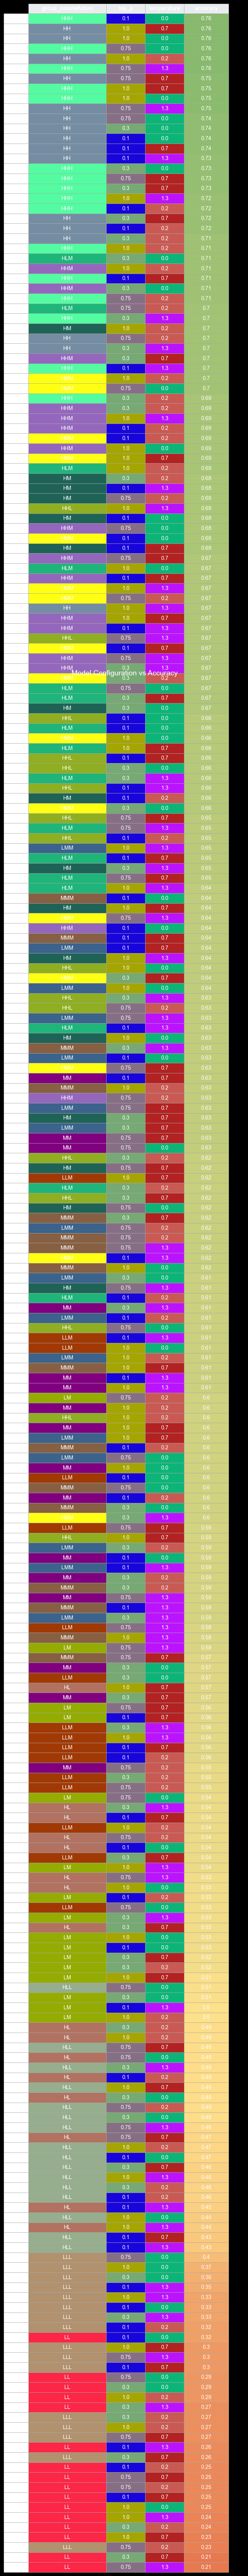

In [24]:
import random

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, get_named_colors_mapping

data = diversity_data.to_numpy()

col_labels = ["group_constellation", "top_p", "temperature", "accuracy"]
row_labels = [f"Run {i + 1}" for i in range(len(data))]

# ────────────────────────────────────────────────
# Color gradient: red → white → green for accuracy
# ────────────────────────────────────────────────

colors = ["#d73027", "#fee08b", "#1a9850"]  # red – light yellow – green
all_colors = list(get_named_colors_mapping().values())
cmap = LinearSegmentedColormap.from_list("acc", colors, N=256)


def acc_to_color(value):
    """Map accuracy [0,1] → color"""
    # Optional: clip just in case
    v = max(0.0, min(1.0, float(value)))
    return cmap(v)


# ────────────────────────────────────────────────
# Build 2D list of cell background colors
# ────────────────────────────────────────────────

category_colors = defaultdict(lambda: random.choice(all_colors))

cell_colors = []
for row in data:
    row_colors = []
    for j, val in enumerate(row):
        if j == 3:  # accuracy column (0-based index 3)
            color = acc_to_color(val)
        else:
            color = category_colors[val]
        row_colors.append(color)
    cell_colors.append(row_colors)

# ────────────────────────────────────────────────
# Create figure and table
# ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 34))  # adjust as needed
ax.axis("off")

table = ax.table(
    cellText=data,
    cellColours=cell_colors,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colWidths=[0.28, 0.14, 0.14, 0.16],
)

table.auto_set_font_size(False)
table.set_fontsize(10.4)
table.scale(1.2, 1.6)  # horizontal / vertical stretch

# Optional: nicer grid
for (i, j), cell in table.get_celld().items():
    cell.set_edgecolor("#aaaaaa")
    cell.set_linewidth(0.6)
    # Make header row bold / different bg
    if i == 0:
        cell.set_facecolor("#e8ecef")
        cell.set_text_props(weight="bold")

# Optional title
fig.suptitle("Model Configuration vs Accuracy", fontsize=14)

register_materialization(
    "diversity_params_mad_evaluation_colored_table_figure",
    fig,
    "The accuracy for different Group Constellations and parameters in comparison using color to emphasize differences.",
)

fig.savefig("this.svg")

plt.show()